<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2004g.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

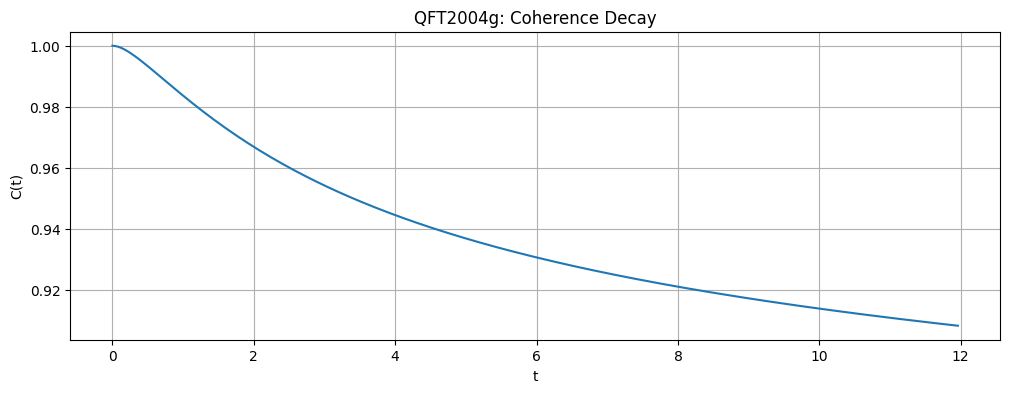

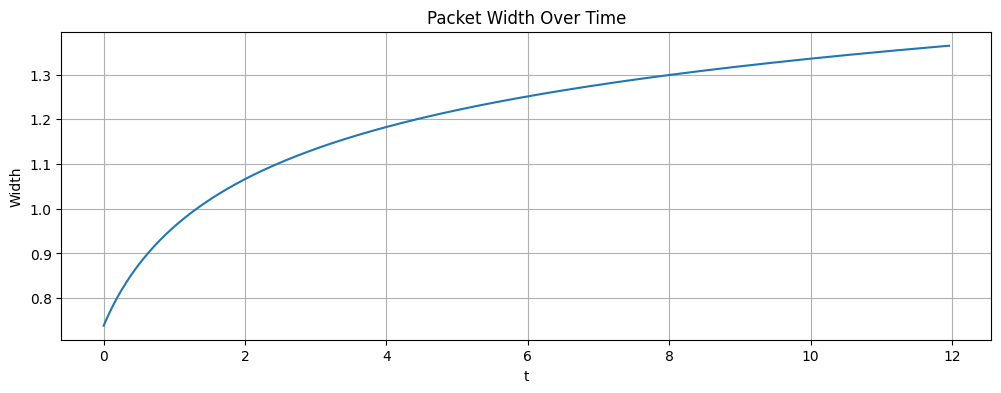

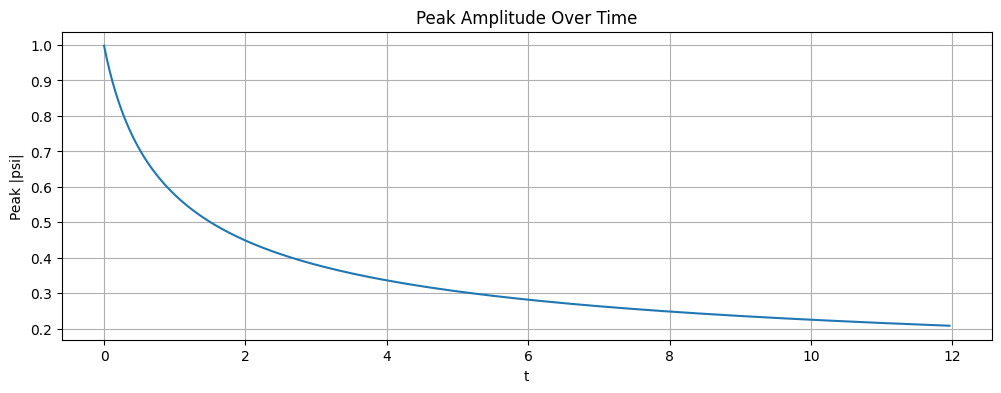

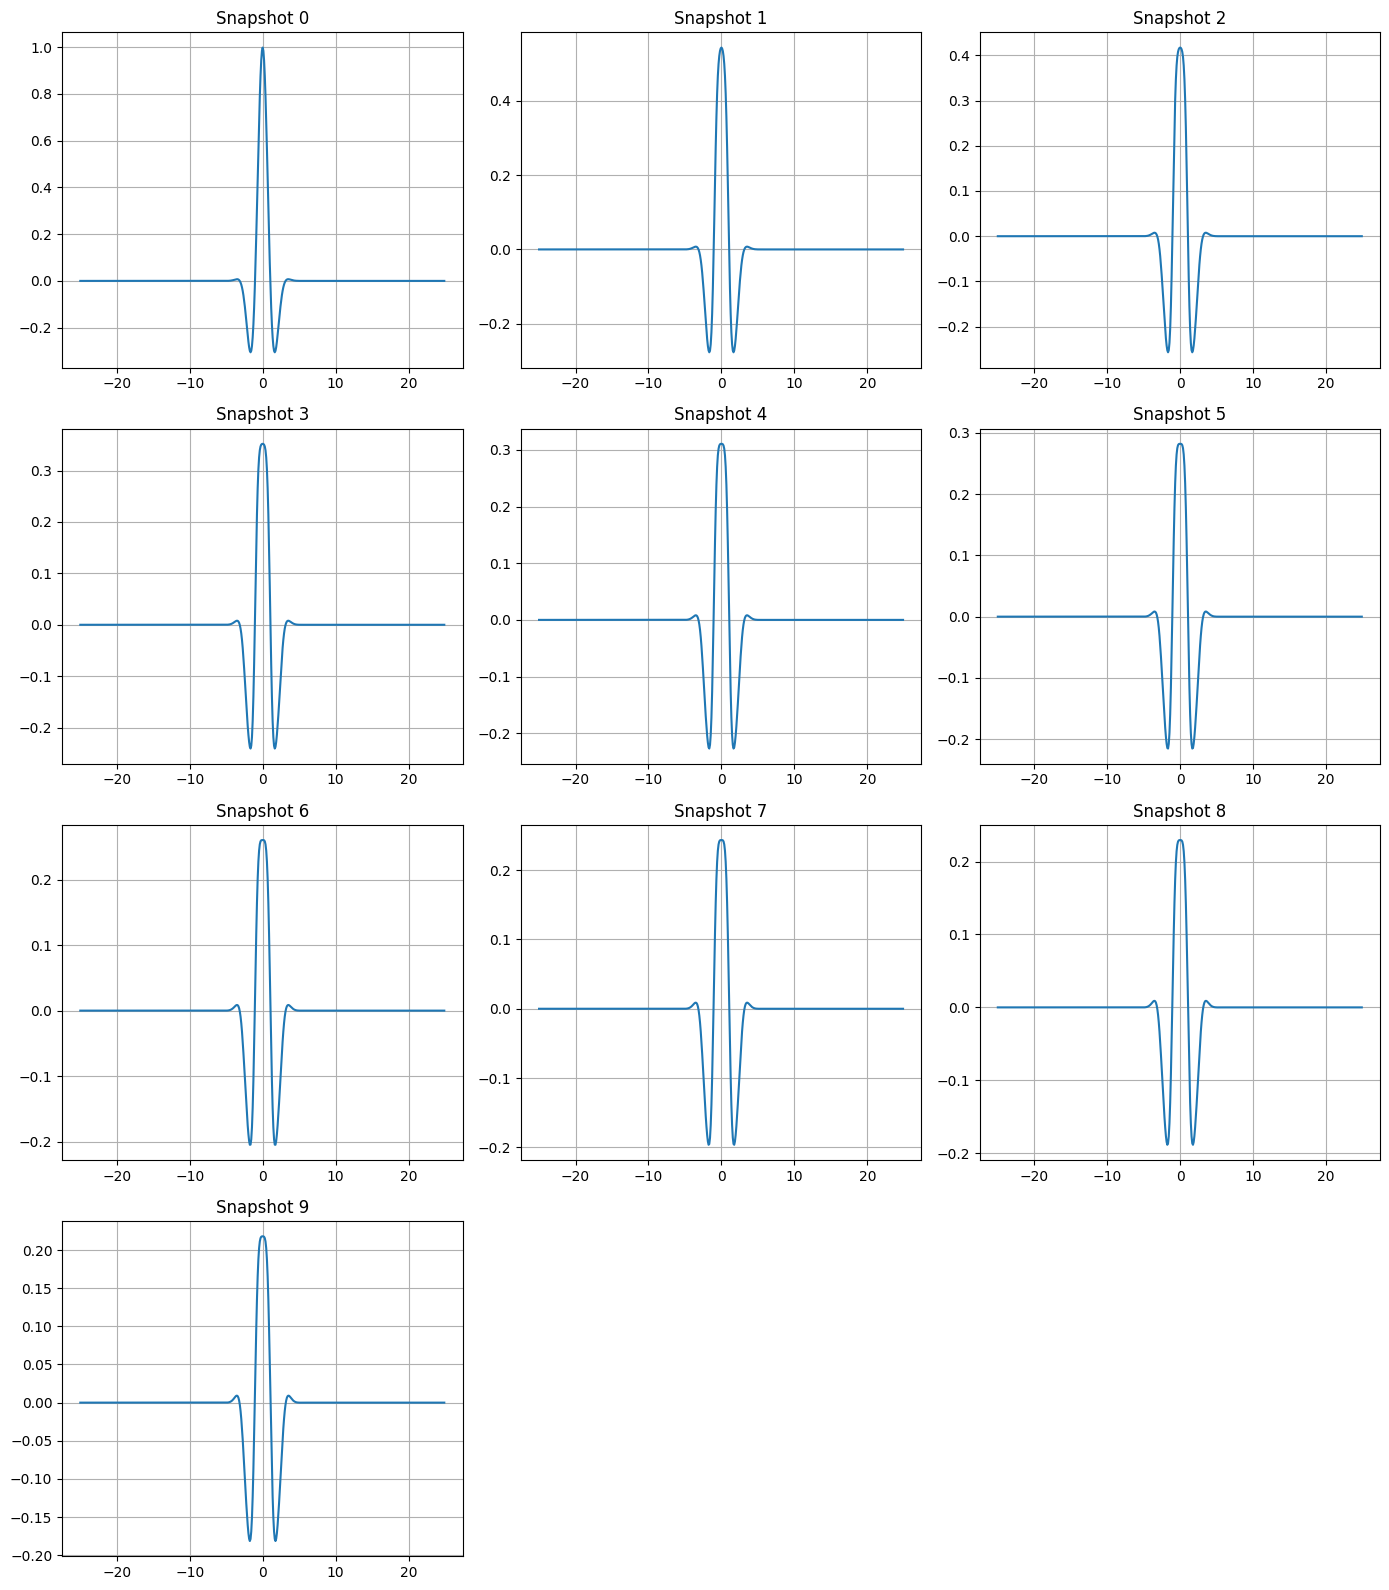

QFT2004g summary:
  Final coherence: 0.9082
  Initial width:   0.7384
  Final width:     1.3646
  Peak amplitude drop: 0.9980 → 0.2085


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004g — Coherence Decay & Shape Memory
# ============================================================

# --- Lattice parameters ---
N = 512
L = 50.0
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)

# --- Time parameters ---
dt = 0.002
steps = 6000
snapshot_interval = 600

# --- Physical parameters ---
m = 1.0
lam = 1.0

# --- Initial packet (same as QFT2004f2 for continuity) ---
A = 1.0
sigma = 1.2
k0 = 1.5

psi0 = A * np.exp(-(x**2)/(2*sigma**2)) * np.cos(k0 * x)
psi = psi0.copy()

# --- Precompute FFT wave numbers ---
k = 2*np.pi * np.fft.fftfreq(N, d=dx)

# --- Storage arrays ---
coherence = []
widths = []
peaks = []
times = []

snapshots = []

# --- Helper functions ---
def compute_width(field):
    norm = np.sum(field**2)
    mean = np.sum(x * field**2) / norm
    var = np.sum((x - mean)**2 * field**2) / norm
    return np.sqrt(var)

def compute_coherence(field, ref):
    num = np.abs(np.sum(field * ref))
    den = np.sqrt(np.sum(field**2) * np.sum(ref**2))
    return num / den

# ============================================================
# Time evolution loop
# ============================================================
for step in range(steps):
    # --- Nonlinear term ---
    psi_nl = psi - dt * lam * psi**3

    # --- Linear term via FFT ---
    psi_k = np.fft.fft(psi_nl)
    psi_k *= np.exp(-0.5j * (k**2 / m) * dt)
    psi = np.real(np.fft.ifft(psi_k))

    # --- Diagnostics ---
    if step % 20 == 0:
        t = step * dt
        times.append(t)
        coherence.append(compute_coherence(psi, psi0))
        widths.append(compute_width(psi))
        peaks.append(np.max(np.abs(psi)))

    if step % snapshot_interval == 0:
        snapshots.append(psi.copy())

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(12,4))
plt.plot(times, coherence, label="Coherence C(t)")
plt.xlabel("t")
plt.ylabel("C(t)")
plt.title("QFT2004g: Coherence Decay")
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(times, widths, label="Width(t)")
plt.xlabel("t")
plt.ylabel("Width")
plt.title("Packet Width Over Time")
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(times, peaks, label="Peak Amplitude(t)")
plt.xlabel("t")
plt.ylabel("Peak |psi|")
plt.title("Peak Amplitude Over Time")
plt.grid()
plt.show()

# --- Snapshot grid ---
cols = 3
rows = int(np.ceil(len(snapshots)/cols))
plt.figure(figsize=(14, 4*rows))

for i, snap in enumerate(snapshots):
    plt.subplot(rows, cols, i+1)
    plt.plot(x, snap)
    plt.title(f"Snapshot {i}")
    plt.grid()

plt.tight_layout()
plt.show()

# ============================================================
# Printed summary
# ============================================================
print("QFT2004g summary:")
print(f"  Final coherence: {coherence[-1]:.4f}")
print(f"  Initial width:   {widths[0]:.4f}")
print(f"  Final width:     {widths[-1]:.4f}")
print(f"  Peak amplitude drop: {peaks[0]:.4f} → {peaks[-1]:.4f}")
